# Tekstdetektion på Chest X-Ray billeder (OpenCV + pytesseract)

Denne notebook scanner chest X-ray billeder for tekst/bogstaver ved hjælp af **OpenCV** til billedbehandling og **pytesseract** (Tesseract OCR) til tegngenkendelse.

**Hvad den gør:**
- Indlæser et røntgenbillede
- Forbehandler billedet (thresholding, denoising) til bedre OCR-nøjagtighed
- Detekterer bogstaver/tekst med pytesseract
- Tæller antallet af tegn og ord
- Tegner bounding boxes rundt om fundne tekstregioner

In [1]:
# Installer nødvendige pakker (kør én gang)
# pip install opencv-python pytesseract pillow matplotlib numpy
# OBS: Tesseract-binær skal også installeres på systemet:
#   Windows: https://github.com/UB-Mannheim/tesseract/wiki
#   Sæt stien nedenfor hvis det ikke er på PATH

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["opencv-python", "pytesseract", "pillow", "matplotlib", "numpy"]:
    install(pkg)

print("Pakker installeret ✓")

Pakker installeret ✓


In [2]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# --- Sti til Tesseract (Windows) ---
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# --- Sæt stien til et enkelt X-ray billede her ---
IMAGE_PATH = r"..\billeder\chest_xray\test\NORMAL\IM-0001-0001.jpeg"   # <-- SKIFT EFTER BEHOV

print("Imports OK ✓")

Imports OK ✓


## 1. Indlæs og forbehandl billedet

Røntgenbilleder har ofte lys tekst på mørk baggrund. Vi:
1. Konverterer til gråskala
2. Inverterer billedet (hvid baggrund, sort tekst – bedre for OCR)
3. Anvender adaptiv thresholding for at fremhæve tekstpixels
4. Fjerner støj med morphological operationer

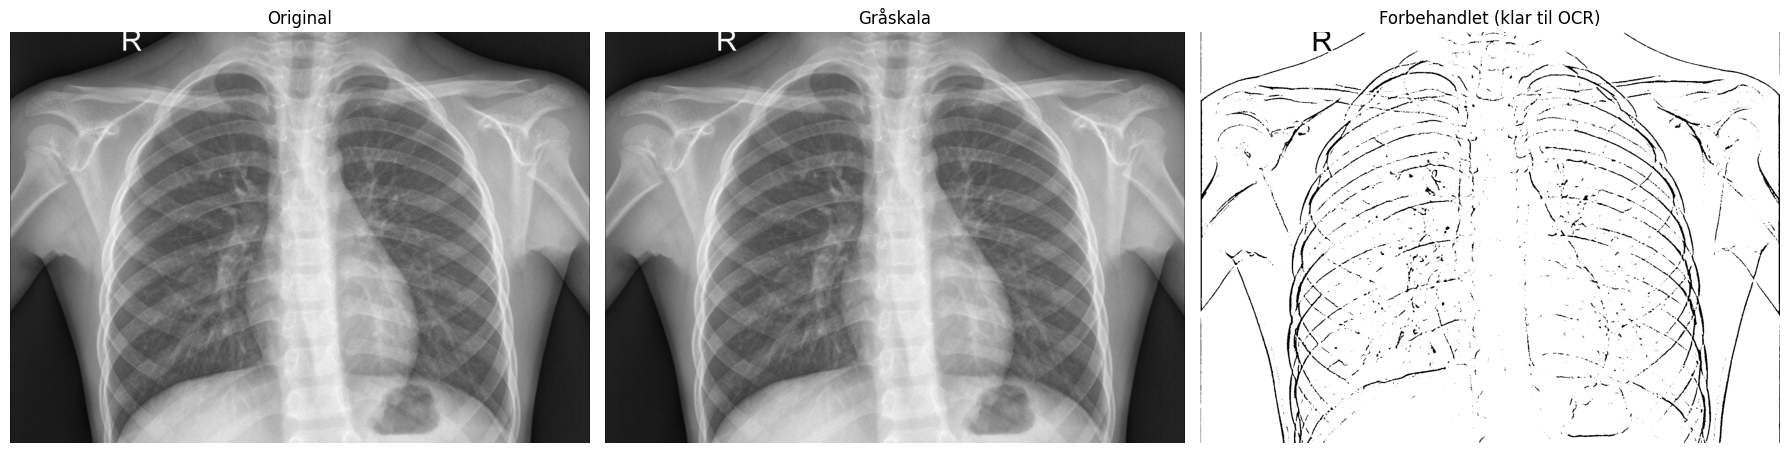

Billedstørrelse: 1857×1317 px


In [3]:
def load_and_preprocess(image_path):
    """
    Indlæser et billede og forbereder det til OCR.
    Returnerer: (original_bgr, grå, forbehandlet)
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Kunne ikke indlæse: {image_path}")

    # Gråskala
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Invert: røntgen er typisk lys tekst på sort -> gør til sort tekst på hvid
    inverted = cv2.bitwise_not(gray)

    # Fjern støj
    denoised = cv2.fastNlMeansDenoising(inverted, h=10)

    # Adaptiv thresholding – god til uens belysning
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # Morphological åbning: fjerner små støjpunkter
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    return img_bgr, gray, cleaned


# Indlæs billedet
img_bgr, gray, preprocessed = load_and_preprocess(IMAGE_PATH)

# Vis original og forbehandlet
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Gråskala")
axes[1].axis("off")

axes[2].imshow(preprocessed, cmap="gray")
axes[2].set_title("Forbehandlet (klar til OCR)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Billedstørrelse: {img_bgr.shape[1]}×{img_bgr.shape[0]} px")

## 2. OCR - Find kun R-markoren med valgfrit sogeomrade (ROI)

Hvis R er sort/svaer at laese, kan vi:
- Saenke konfidenskravet
- Prove flere billedversioner (gra, inverteret, threshold)
- Soege kun i et bestemt omrade (ROI), fx overst til venstre

Skift `ROI_MODE` i cellen nedenfor: `full`, `top_band`, `top_left` eller `manual`.

In [4]:
def _get_roi_box(img_shape, roi_mode="top_left", manual_roi=None):
    """Returnerer (x1, y1, x2, y2) for sogeomradet."""
    h, w = img_shape[:2]
    if roi_mode == "full":
        return (0, 0, w, h)
    if roi_mode == "top_band":
        return (0, 0, w, int(0.45 * h))
    if roi_mode == "top_left":
        return (0, 0, int(0.38 * w), int(0.30 * h))
    if roi_mode == "manual" and manual_roi is not None:
        x1, y1, x2, y2 = manual_roi
        x1 = max(0, min(int(x1), w - 1))
        y1 = max(0, min(int(y1), h - 1))
        x2 = max(x1 + 1, min(int(x2), w))
        y2 = max(y1 + 1, min(int(y2), h))
        return (x1, y1, x2, y2)
    return (0, 0, w, h)


def detect_r_marker(gray_img, preprocessed_img, conf_threshold=20, roi_mode="top_left", manual_roi=None):
    """Finder kun R-markoren via OCR med whitelist og valgfri ROI."""
    x1, y1, x2, y2 = _get_roi_box(gray_img.shape, roi_mode, manual_roi)
    roi_gray = gray_img[y1:y2, x1:x2]
    roi_inv = cv2.bitwise_not(roi_gray)
    roi_pre = preprocessed_img[y1:y2, x1:x2]
    _, roi_otsu = cv2.threshold(roi_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    variants = [roi_gray, roi_inv, roi_pre, roi_otsu]
    configs = [
        r"--oem 3 --psm 10 -c tessedit_char_whitelist=Rr",
        r"--oem 3 --psm 11 -c tessedit_char_whitelist=Rr",
    ]

    candidates = []
    for variant in variants:
        for cfg in configs:
            data = pytesseract.image_to_data(variant, config=cfg, output_type=pytesseract.Output.DICT)
            for i in range(len(data["text"])):
                txt = (data["text"][i] or "").strip()
                if txt not in {"R", "r"}:
                    continue
                try:
                    conf = float(data["conf"][i])
                except (TypeError, ValueError):
                    conf = -1.0
                if conf < conf_threshold:
                    continue

                bx = int(data["left"][i]) + x1
                by = int(data["top"][i]) + y1
                bw = int(data["width"][i])
                bh = int(data["height"][i])

                if bw * bh < 20:
                    continue
                ratio = bh / max(bw, 1)
                if ratio < 0.6 or ratio > 4.0:
                    continue

                score = conf + 0.02 * (bw * bh)
                candidates.append({
                    "text": "R",
                    "conf": round(conf, 1),
                    "x": bx,
                    "y": by,
                    "w": bw,
                    "h": bh,
                    "score": score,
                })

    if not candidates:
        return [], (x1, y1, x2, y2)
    best = max(candidates, key=lambda d: d["score"])
    best.pop("score", None)
    return [best], (x1, y1, x2, y2)


def detect_text(preprocessed_img, conf_threshold=20):
    """Bagudkompatibel wrapper til mappe-scan (uden gray/ROI-kontrol)."""
    dets, _ = detect_r_marker(preprocessed_img, preprocessed_img, conf_threshold=conf_threshold, roi_mode="full")
    return dets


# Vaelg sogeomrade: full | top_band | top_left | manual
ROI_MODE = "top_left"
MANUAL_ROI = (20, 5, 220, 120)  # bruges kun hvis ROI_MODE = "manual"

detections, roi_box = detect_r_marker(
    gray,
    preprocessed,
    conf_threshold=20,
    roi_mode=ROI_MODE,
    manual_roi=MANUAL_ROI,
)

print("=" * 45)
print(f"  ROI mode            : {ROI_MODE}")
print(f"  ROI box (x1,y1,x2,y2): {roi_box}")
print(f"  Kandidater (R)      : {len(detections)}")
print(f"  Fundet R-markor     : {'ja' if detections else 'nej'}")
if detections:
    d = detections[0]
    print(f"  Position (x,y,w,h)  : ({d['x']}, {d['y']}, {d['w']}, {d['h']})")
    print(f"  Konfidens           : {d['conf']}%")
print("=" * 45)

  ROI mode            : top_left
  ROI box (x1,y1,x2,y2): (0, 0, 705, 395)
  Kandidater (R)      : 0
  Fundet R-markor     : nej


## 3. Visualiser fundet R-markor

Tegner en grøn bounding box omkring den bedste detekterede R-markor.

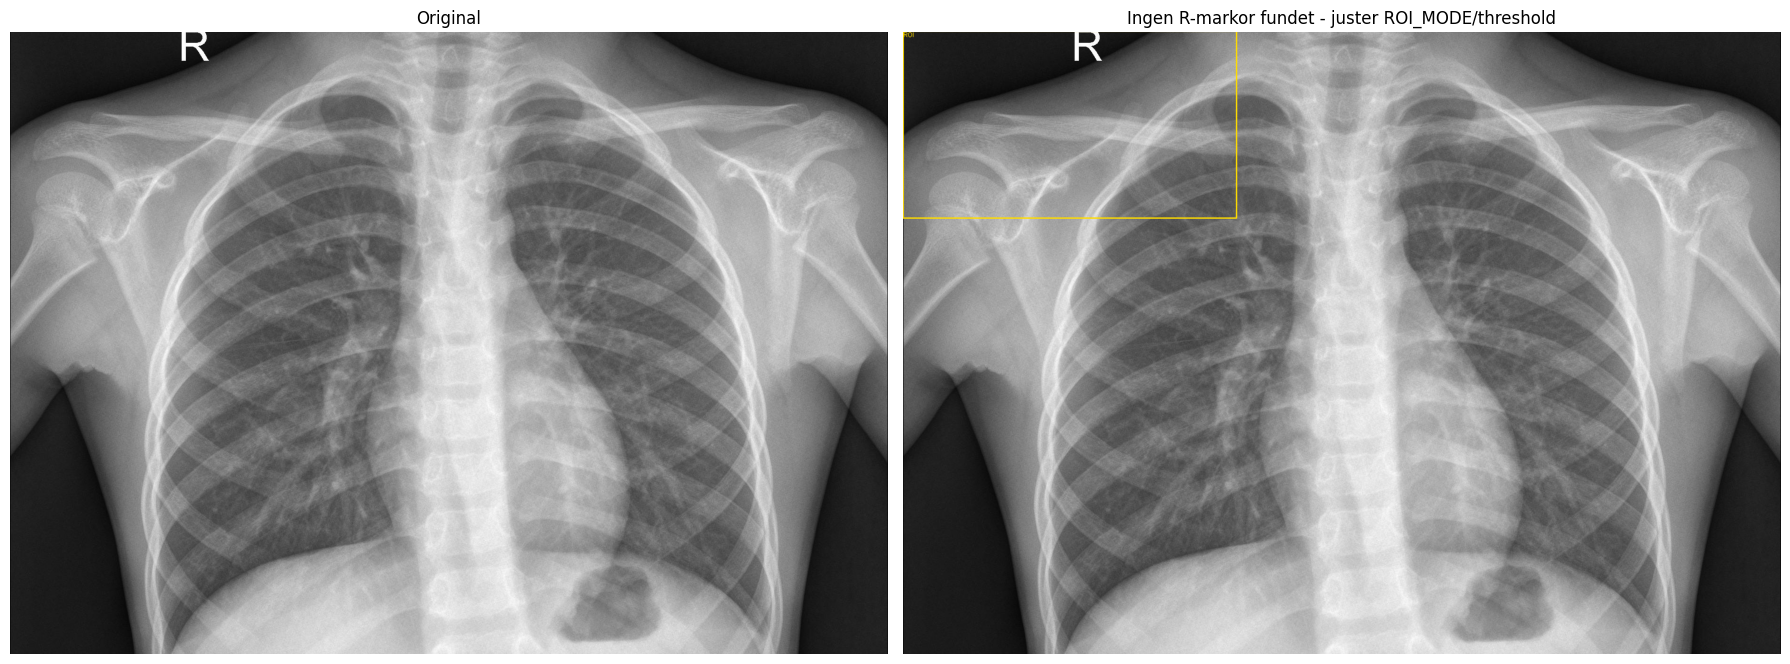

In [5]:
def draw_detections(img_bgr, detections, roi_box=None):
    """Tegner ROI (gul) og R-detektion (gron) pa en kopi af billedet."""
    annotated = img_bgr.copy()

    if roi_box is not None:
        x1, y1, x2, y2 = roi_box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 220, 255), 2)
        cv2.putText(
            annotated, "ROI",
            (x1, max(12, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 220, 255), 1, cv2.LINE_AA
        )

    for d in detections:
        x, y, w, h = d["x"], d["y"], d["w"], d["h"]
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
        label = f"{d['text']} ({d['conf']}%)"
        cv2.putText(
            annotated, label,
            (x, max(y - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1,
            cv2.LINE_AA
        )
    return annotated


annotated_img = draw_detections(img_bgr, detections, roi_box=roi_box)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
if detections:
    axes[1].set_title("Detekteret R-markor (gron) + ROI (gul)")
else:
    axes[1].set_title("Ingen R-markor fundet - juster ROI_MODE/threshold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4. Scan en hel mappe med billeder

Nyttigt når du vil processere alle billeder i Chest X-Ray datasættet på én gang og gemme resultaterne.

In [6]:
import os
import pandas as pd

# --- Sæt sti til mappe med billeder ---
FOLDER_PATH = r"..\billeder\chest_xray\test\NORMAL"   # <-- SKIFT EFTER BEHOV (fx test\PNEUMONIA, train\NORMAL osv.)
EXTENSIONS  = {".png", ".jpg", ".jpeg"}

rows = []
for fname in os.listdir(FOLDER_PATH):
    if os.path.splitext(fname)[1].lower() not in EXTENSIONS:
        continue

    fpath = os.path.join(FOLDER_PATH, fname)
    try:
        _, _, prep = load_and_preprocess(fpath)
        dets = detect_text(prep)

        all_text  = " ".join(d["text"] for d in dets)
        n_chars   = sum(len(d["text"]) for d in dets)
        n_letters = sum(1 for c in all_text if c.isalpha())
        n_words   = len(all_text.split())

        rows.append({
            "fil":          fname,
            "tekst_blokke": len(dets),
            "ord":          n_words,
            "tegn_total":   n_chars,
            "bogstaver":    n_letters,
            "fundet_tekst": all_text.strip(),
        })
        print(f"✓  {fname:40s}  blokke={len(dets):3d}  tegn={n_chars:4d}")
    except Exception as e:
        print(f"✗  {fname}  →  {e}")

df = pd.DataFrame(rows)
print("\n\n=== Opsummering ===")
print(df.to_string(index=False))

# Gem til CSV
output_csv = os.path.join(FOLDER_PATH, "tekst_scanner_resultater.csv")
df.to_csv(output_csv, index=False)
print(f"\nGemt: {output_csv}")

✓  IM-0001-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0003-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0005-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0006-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0007-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0009-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0010-0001.jpeg                         blokke=  0  tegn=   0
✓  IM-0011-0001-0001.jpeg                    blokke=  0  tegn=   0
✓  IM-0011-0001-0002.jpeg                    blokke=  0  tegn=   0
✓  IM-0011-0001.jpeg                         blokke=  0  tegn=   0


KeyboardInterrupt: 